# Fare Amount Prediction


### 1) Problem Statement
* This problem understands how the fare amount of a uber trip is affected by variables like, Distance_km, Payment Method, Status and others variables.

## 2)Data Collection 
* Dataset Source - (https://www.kaggle.com/datasets/rohiteng/uber-trips-dataset)
* The Data consists of 14 columns and 50,000 rows 

## 2.1 Import Data and Required Packages

### Importing Pandas, Numpy, Matplotlob, Seaborn and warning Library

In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Importing the CSV Data as a Pandas DataFrame using Kagglehub

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohiteng/uber-trips-dataset")

print("Path to dataset files:", path)
df_path = path + "\\uber_trips_dataset_50k.csv"
df = pd.read_csv(df_path)


Path to dataset files: C:\Users\samue\.cache\kagglehub\datasets\rohiteng\uber-trips-dataset\versions\1


### Dataset Shape

In [4]:
print(df.shape)

(50000, 14)


### Show top 10 Records

In [5]:
print(df.head())

   trip_id  driver_id  rider_id           city  pickup_lat  pickup_lng  \
0        1       8270     10683  San Francisco   37.170931  -77.586479   
1        2       1860     44743         Boston   38.898127 -108.582977   
2        3       6390     75839  San Francisco   38.814571  -89.942603   
3        4       6191     22189       New York   37.295906  -75.328844   
4        5       6734     61104        Seattle   38.972395 -121.482913   

    drop_lat    drop_lng  distance_km  fare_amount     status payment_method  \
0  37.173652  -77.619934         2.97        10.71  Completed         Wallet   
1  38.937464 -108.558727         8.43        22.41  Completed            UPI   
2  38.821702  -89.896435         5.46        12.91  Completed           Cash   
3  37.301375  -75.317488         6.61        15.70  Completed         Wallet   
4  38.992088 -121.467904        10.50        19.15  Completed         Wallet   

           pickup_time                      drop_time  
0  2023-01-01 00:0

## 2.2 Dataset Information
* trip_id : Unique ID of the trip 
* driver_id : Unique ID of the driver
* rider_id : Unique Id of the passenger
* city : City where the trip occured
* pickup_lat : Latitude coordinates of the pickup place
* pickup_lng : Longitude coordinates of the pickup place
* drop_lat : Latitude coordinates of the drop place
* drop_lng : Longitude coordinates of the pickup place
* distance_km : Distance in Kilometers of the trip
* fare_amount : Value to Pay
* status : Trip Status
* payment_method : trip Payment Method
* pickup_time : Date and Time of the Pickup
* drop_time : Date and Time of the Drop

## 3) Data Checks to Perform
* Check Missing Values
* Check Duplicates
* Check Datatype
* Check the number of unique values of each column
* Check statistics of data set
* Check various categories present in the different categorical column

### 3.1 Check Missing Values

In [6]:
df.isna().sum()

trip_id           0
driver_id         0
rider_id          0
city              0
pickup_lat        0
pickup_lng        0
drop_lat          0
drop_lng          0
distance_km       0
fare_amount       0
status            0
payment_method    0
pickup_time       0
drop_time         0
dtype: int64

###  There are no missing values in the dataset

### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

0

### There are no Duplicated values in the dataset

### 3.3 Check Datatype

In [8]:
df.dtypes

trip_id             int64
driver_id           int64
rider_id            int64
city               object
pickup_lat        float64
pickup_lng        float64
drop_lat          float64
drop_lng          float64
distance_km       float64
fare_amount       float64
status             object
payment_method     object
pickup_time        object
drop_time          object
dtype: object

### 3.4 Check the number of unique values of each column

In [9]:
df.nunique()

trip_id           50000
driver_id          8963
rider_id          38352
city                  6
pickup_lat        50000
pickup_lng        50000
drop_lat          50000
drop_lng          50000
distance_km        1623
fare_amount        3402
status                3
payment_method        4
pickup_time       50000
drop_time         49746
dtype: int64

### 3.5 Check statistics of data set

In [10]:
df.describe()


,trip_id,driver_id,rider_id,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,5493.954540,55040.994580,38.998664,-97.485552,38.998768,-97.485677,7.008070,15.976205
std,14433.901067,2601.410798,25915.467105,1.155241,14.173744,1.155696,14.173735,2.946744,6.274406
min,1.000000,1000.000000,10001.000000,37.000009,-121.999465,36.953365,-122.047124,0.000000,1.080000
25%,12500.750000,3232.750000,32539.000000,37.994428,-109.818282,37.998237,-109.817260,4.980000,11.510000
50%,25000.500000,5497.000000,55164.000000,38.992589,-97.463042,38.994190,-97.464646,6.980000,15.430000
75%,37500.250000,7746.000000,77293.500000,39.999602,-85.190954,39.998849,-85.199652,9.000000,19.910000
max,50000.000000,9998.000000,99998.000000,40.999937,-73.001961,41.047536,-72.963476,19.410000,50.670000


### Insights
* The medium fare_amount:15.97, max fare_amount: 50.67, min fare_amount: 1.08 

### 3.6 Check various categories present in the different categorical column

In [11]:
#numerical and categorical features
numerical_features= [[feature for feature in df.columns if (df[feature].dtype != "object")]]
categorical_features = [feature for feature in df.columns if (df[feature].dtype == "object")]

print("we have {} numerical features : {}".format(len(numerical_features),numerical_features))
print("we have {} categorical features : {}".format(len(categorical_features),categorical_features))

we have 1 numerical features : [['trip_id', 'driver_id', 'rider_id', 'pickup_lat', 'pickup_lng', 'drop_lat', 'drop_lng', 'distance_km', 'fare_amount']]
we have 5 categorical features : ['city', 'status', 'payment_method', 'pickup_time', 'drop_time']


In [12]:
print("Categories in city variable:      ",end="  ")
print(df['city'].unique())
print("Categories in payment method variable:      ",end="  ")
print(df['payment_method'].unique())
print("Categories in status variable:      ",end="  ")
print(df['status'].unique())

Categories in city variable:        ['San Francisco' 'Boston' 'New York' 'Seattle' 'Chicago' 'Los Angeles']
Categories in payment method variable:        ['Wallet' 'UPI' 'Cash' 'Card']
Categories in status variable:        ['Completed' 'No-Show' 'Cancelled']


### 3.7 Adjuste drop_time

In [13]:
#clean drop_time feature to remove miliseconds
a = []
for line in df['drop_time']:
    x,y = line.split('.')
    a.append(x)
    
df_drop_clean = pd.DataFrame(a,columns=['drop_time'])
df.drop(columns=['drop_time'],inplace=True)
df = pd.concat([df,df_drop_clean],axis=1)

## 4) Feature Engineering


In [14]:
p_time = pd.to_datetime(df['pickup_time'])
d_time = pd.to_datetime(df['drop_time'])
dif_drop_pickup = (d_time - p_time) 
dif_drop_pickup = dif_drop_pickup.dt.components.apply(
    lambda x: f"{x['hours']:02d}:{x['minutes']:02d}:{x['seconds']:02d}", axis=1
)
print(dif_drop_pickup)


0        00:08:54
1        00:25:17
2        00:16:22
3        00:19:49
4        00:31:30
           ...   
49995    00:22:10
49996    00:14:40
49997    00:12:34
49998    00:06:55
49999    00:29:54
Length: 50000, dtype: object


In [15]:
df['pickup_hour'] = df['pickup_time'].astype('datetime64[ns]').dt.hour
df['pickup_month'] = df['pickup_time'].astype('datetime64[ns]').dt.month
df['pickup_day'] = df['pickup_time'].astype('datetime64[ns]').dt.day
df['weekday'] = df['pickup_time'].astype('datetime64[ns]').dt.day_of_week
df['weekend'] = (df['weekday']>=5).astype(int)
df['rush_hour'] = (((df['pickup_hour'] >= 7) & (df['pickup_hour'] <= 9))|(  ( df['pickup_hour']>= 17) & (df['pickup_hour'] <= 19))).astype(int)
df['distance_hour'] = df['distance_km'] * df['pickup_hour']
df['squared_distance'] = df['distance_km'] **2
df['delta_lat'] = df['drop_lat'] - df['pickup_lat']
df['delta_long'] = df['drop_lng'] - df['pickup_lng']

print(df['pickup_hour'].unique())
print(df['pickup_month'].unique())
print(df['pickup_day'].unique())
print(df['weekday'].unique())
print(df['weekend'].unique())
print(df['rush_hour'].unique())
print(df['distance_hour'].unique())
print(df['squared_distance'].unique())
print(df['delta_lat'].unique())
print(df['delta_long'].unique())


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[1 2]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
[6 0 1 2 3 4 5]
[1 0]
[0 1]
[  0.     0.37   4.4  ... 168.32  60.86  69.87]
[  8.8209  71.0649  29.8116 ... 247.4329 235.3156 230.1289]
[0.00272119 0.03933688 0.00713179 ... 0.04177931 0.02341875 0.0337606 ]
[-0.03345497  0.02424978  0.04616815 ...  0.04825355  0.00293159
 -0.01690643]


In [16]:
from sklearn.cluster import KMeans

kmeans_1 = KMeans(n_clusters=20,random_state=42)
kmeans_2 = KMeans(n_clusters=20,random_state=42)

coords_pickup = df[["pickup_lat","pickup_lng"]]
coords_drop = df[["drop_lat","drop_lng"]]

kmeans_1.fit(coords_pickup)
kmeans_2.fit(coords_drop)

pickup_cluster = kmeans_1.predict(coords_pickup)
drop_cluster = kmeans_2.predict(coords_drop)



  File "c:\Users\samue\anaconda3\envs\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\samue\anaconda3\envs\venv\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\samue\anaconda3\envs\venv\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\samue\anaconda3\envs\venv\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


In [17]:
def haversine(lat1,long1,lat2,long2):
    R = 6371

    lat1 = np.radians(lat1)
    long1 = np.radians(long1)
    lat2 = np.radians(lat2)
    long2 = np.radians(long2)

    dlat = lat2 - lat1
    dlong = long2 - long1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R*c



In [18]:
pickup_cluster = pd.Series(pickup_cluster,name='pickup_cluster')
drop_cluster = pd.Series(drop_cluster,name='drop_cluster')
df['haversine_distance'] = haversine(df['pickup_lat'],df['pickup_lng'],df['drop_lat'],df['drop_lng'])

print(df['haversine_distance'])
print(df['haversine_distance'].unique())
print(pickup_cluster.unique())
print(drop_cluster.unique())

0        2.979600
1        4.851174
2        4.077696
3        1.174280
4        2.545195
           ...   
49995    5.821265
49996    6.101300
49997    6.317337
49998    2.616822
49999    4.018414
Name: haversine_distance, Length: 50000, dtype: float64
[2.97960023 4.85117393 4.07769628 ... 6.31733733 2.61682181 4.01841428]
[ 8  1 18  0 13 14 16 15  2 17 12 19  4  3 11  5 10  7  6  9]
[15  7 14  6 18 13  8  1  4  5  0  3 17 16 12  2 11 10  9 19]


In [19]:
df = pd.concat([df,df['haversine_distance'],pickup_cluster,drop_cluster,dif_drop_pickup,df['pickup_hour'],df['pickup_month'],df['pickup_day'],df['weekday'],df['weekend'],df['rush_hour'],df['distance_hour'],df['squared_distance'],df['delta_lat'],df['delta_long']],axis=1)
print(df)

       trip_id  driver_id  rider_id           city  pickup_lat  pickup_lng  \
0            1       8270     10683  San Francisco   37.170931  -77.586479   
1            2       1860     44743         Boston   38.898127 -108.582977   
2            3       6390     75839  San Francisco   38.814571  -89.942603   
3            4       6191     22189       New York   37.295906  -75.328844   
4            5       6734     61104        Seattle   38.972395 -121.482913   
...        ...        ...       ...            ...         ...         ...   
49995    49996       4836     99552         Boston   39.087594  -92.313909   
49996    49997       8309     35750    Los Angeles   39.629770  -83.081404   
49997    49998       8381     36652  San Francisco   37.052628  -89.241586   
49998    49999       5474     43848        Chicago   37.588881 -117.889704   
49999    50000       9683     34776  San Francisco   40.292170 -112.706632   

        drop_lat    drop_lng  distance_km  fare_amount  ... pic

## Created Features 
* dif_drop_pickup : The difference between drop_time and pickup_time
* pickup_hour : Hour when the trip started
* pickup_day : Day when the trip occured
* weekday : Weekday when the trip occured
* weekend : If the trip occured in weekend or not 
* rush_hour : If the trip occured in rush hour or not
* distance_hour : The product of distance_km and pickup_hour
* squared_distance : The distance squared
* delta_lat : The difference between drop_lat and pickup_lat
* delta_long : The difference between drop_lng and pickup_lng
* pickup_cluster : The pickup coordinates were converted in clusters
* drop_cluster : The drop coordinates were converted in clusters
* haversine_distance : Straight-line distance between pickup and drop-off coordinates.

# 4) Visualization 

### Fare Amount distribution

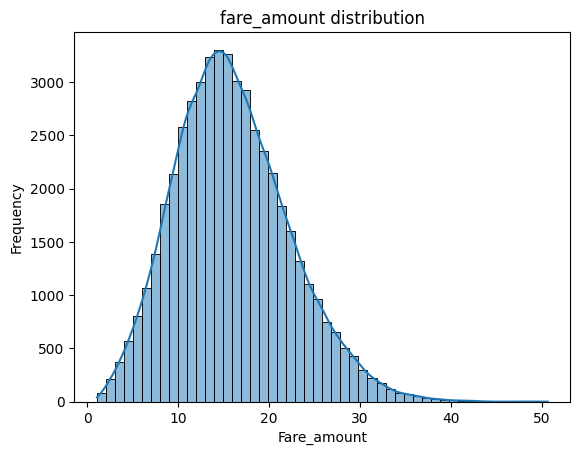

In [20]:
sns.histplot(df['fare_amount'],bins=50,kde=True)
plt.title('fare_amount distribution')
plt.xlabel('Fare_amount')
plt.ylabel('Frequency')
plt.show()

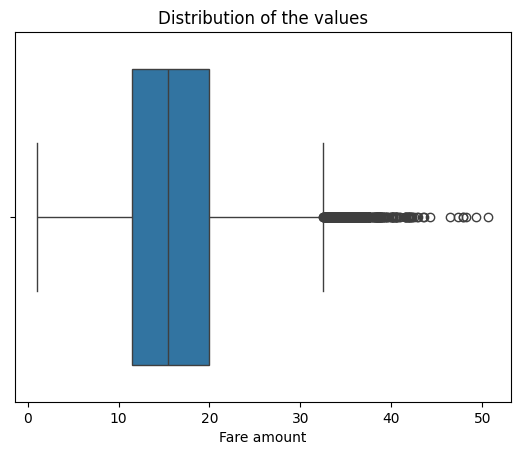

In [21]:
fig,ax = plt.subplots()

sns.boxplot(x=df['fare_amount'], ax=ax)

ax.set_title('Distribution of the values')
ax.set_xlabel('Fare amount')

plt.show()

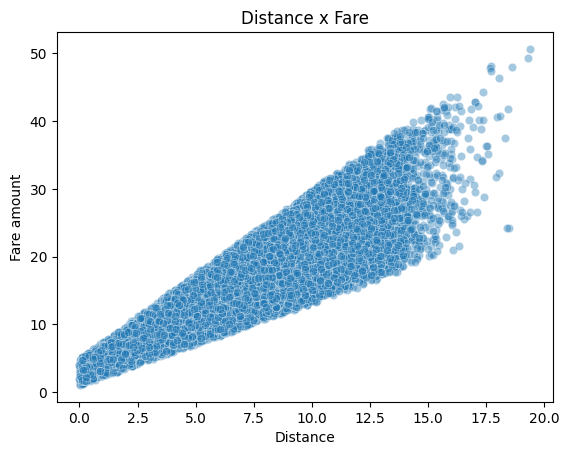

In [22]:
sns.scatterplot(
    data=df,
    x='distance_km',
    y = 'fare_amount',
    alpha=0.4
)

plt.title('Distance x Fare')
plt.xlabel('Distance')
plt.ylabel('Fare amount')

plt.show()

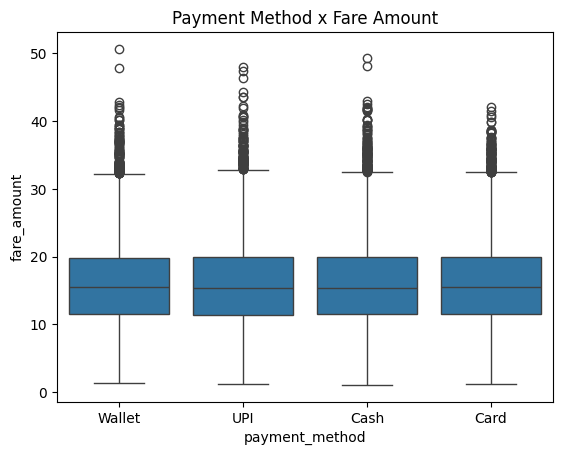

In [ ]:
sns.boxplot(
    data=df,
    x='payment_method',
    y='fare_amount'
)
plt.title('Payment Method x Fare Amount')
plt.show()